In [2]:
from vmc_importance import output_dir, get_system, get_network
from vmc_importance_config import default_config, get_config
from itertools import chain
from misc_utils import read_jsonl_to_df, keep_serializable
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from misc_utils import smooth, column_to
from vmc_amplitude import get_csr_hamiltonian
import torch

Running dilated_nns_xors.py


In [3]:
# load_tasks = ["80", "84", "85", "86", "87"]
# load_tasks = ["80", "88", "89", "92", "93", "94", "95", "96", "97", "98", "100", "101"]
load_tasks = ["2", "3", "4"]
df = (
    read_jsonl_to_df(
        chain(*[list(output_dir.glob(f"{task}/results.jsonl")) for task in load_tasks])
        #   + list(output_dir.glob("58/results.jsonl"))
    )
    .fillna({k: v for k, v in keep_serializable(default_config).items()})
    .fillna({"run": 0})
    # .assign(
    #     n_signs_updated=lambda df: df.groupby("task_id")["signs_updated"].transform(
    #         "cumsum"
    #     )
    # )
)

In [4]:
from datetime import datetime
from datetime import datetime

timestamp = "2024_05_02_00_54_45"
format = "%Y_%m_%d_%H_%M_%S"

parsed_timestamp = datetime.strptime(timestamp, format)
print(parsed_timestamp)

2024-05-02 00:54:45


In [5]:
(lambda x: (x.iloc[-1] - x.iloc[0]))(
    df.query("task_id == 2")["current_timestamp"].apply(
        lambda x: datetime.strptime(x, format)
    )
)

Timedelta('7 days 18:51:20')

In [6]:
df.query("task_id == 2").rolling(window=100)['amplitude_overlap'].mean().max()

0.9191426193714142

In [7]:
df.columns

Index(['outer_sample_size', 'inner_sample_size', 'inner_epochs', 'lr',
       'weight_decay', 'batch_size', 'max_iter', 'lattice', 'use_symmetries',
       'use_symmetries.basis', 'spin_inversion', 'J2', 'eval_set_max_size',
       'runs', 'resnet_block_depth', 'resnet_blocks', 'dilations',
       'gcnn_additional_generators', 'gcnn_extend_filter1', 'gcnn_filter_size',
       'gcnn_channels', 'gcnn_res_blocks', 'cnn_hidden_channels',
       'cnn_dilations', 'sign_noise', 'device', 'log_prob_fn', 'run',
       'outer_step', 'inner_step', 'step', 'epoch', 'amplitude_overlap',
       'start_timestamp', 'current_timestamp', 'n_inner_samples', 'task_id',
       'git_hash', 'energy_delta', 'true_energy', 'estimated_energy',
       'grad_norm', 'find_exact_energy'],
      dtype='object')

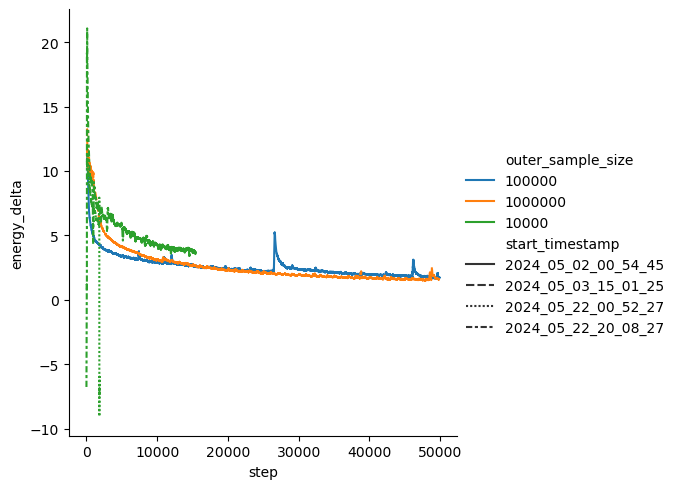

In [11]:
sns.relplot(
    df.query("task_id >= 2")
    .pipe(smooth("amplitude_overlap", 100, ["task_id"]))
    .pipe(smooth("energy_delta", 100, ["task_id"]))
    .astype({"outer_sample_size": str}),
    x="step",
    y="energy_delta",
    kind="line",
    style='start_timestamp',
    hue="outer_sample_size",
)

In [8]:
from ising_sign_reconstruction import reconstruct_signs

In [10]:
task_id = 2
config = get_config(task_id)
system = get_system(config)

In [11]:
log_prob_fn = get_network(config, system)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
matrix = get_csr_hamiltonian(system)

In [14]:
log_prob_fn.to(device)

LogProbFn(
  (net): SplitGroupResConvNet(
    (layer1): GConvLattice()
    (other_layers): ModuleList(
      (0-3): 4 x GConvG()
    )
    (fc): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [18]:
from spin_systems import SpinSystem
import numpy as np
from vmc_amplitude import get_csr_hamiltonian, safe_exp_numpy
from scipy.sparse import diags
import ising_glass_annealer as ising
from collections.abc import Callable
import os
import numpy.typing as npt
import torch
import lattice_symmetries as ls
from scipy.sparse import csr_matrix
from loguru import logger
from nqs_playground_helpers import forward_with_batches


def reconstruct_signs(
    basis: ls.Basis,
    hamiltonian_matrix: csr_matrix,
    log_prob_fn: Callable[[torch.Tensor], torch.Tensor],
    how="annealing",
    number_sweeps: int | None = None,
    repetitions: int | None = None,
    device=torch.device("cpu"),
    force_symmetry=False,
    batch_size=8192,
):
    logger.debug("Finding predicted amplitudes")
    predicted_amplitudes = safe_exp_numpy(
        forward_with_batches(
            f=lambda batch: log_prob_fn(torch.from_numpy(batch).to(device))
            .detach()
            .cpu()
            .numpy(),
            xs=basis.states.astype(np.int64),
            batch_size=batch_size,
        ).reshape(-1)
        * 0.5,
        normalise=False,
    )
    logger.debug("Normalizing amplitudes")
    predicted_amplitudes /= np.linalg.norm(predicted_amplitudes)

    logger.debug("Creating Ising Hamiltonian matrix")
    ising_hamiltonian_matrix = (
        diags(predicted_amplitudes) @ hamiltonian_matrix @ diags(predicted_amplitudes)
    )
    if force_symmetry:
        logger.debug("Forcing symmetry")
        ising_hamiltonian_matrix = (
            ising_hamiltonian_matrix + ising_hamiltonian_matrix.transpose()
        ) / 2
        mask = np.abs(ising_hamiltonian_matrix.data) <= 1e-14
        ising_hamiltonian_matrix.data[mask] = 0
        ising_hamiltonian_matrix.eliminate_zeros()
        logger.debug("Forcing symmetry done")

    logger.debug("Creating ising Hamiltonian")
    ising_hamiltonian = ising.Hamiltonian(
        exchange=ising_hamiltonian_matrix,
        field=np.zeros(ising_hamiltonian_matrix.shape[0]),
    )
    if how == "annealing":
        logger.debug("Using annealing")
        if repetitions is None:
            raise ValueError(
                "If how='annealing', repetitions must be specified, but it was None"
            )
        if number_sweeps is None:
            raise ValueError(
                "If how='annealing', number_sweeps must be specified, but it was None"
            )
        reconstructed_bits = ising.anneal(
            ising_hamiltonian, repetitions=repetitions, number_sweeps=number_sweeps
        )[0]
    elif how == "greedy_solve":
        logger.debug("Using greedy solve")
        reconstructed_bits = ising.greedy_solve(ising_hamiltonian)[0]
    else:
        raise ValueError(f"how={how} not implemented")

    reconstructed_signs = ising.bits_to_signs(
        reconstructed_bits,
        ising_hamiltonian.exchange.shape[0],
    )
    return reconstructed_signs

In [19]:
reconstructed_signs = reconstruct_signs(
    system.basis,
    matrix,
    log_prob_fn,
    how='greedy_solve',
    device=device,
    force_symmetry=True,
)

2024-05-06 14:17:02.382 | DEBUG    | __main__:reconstruct_signs:27 - Finding predicted amplitudes
2024-05-06 14:18:52.854 | DEBUG    | __main__:reconstruct_signs:40 - Normalizing amplitudes
2024-05-06 14:18:52.874 | DEBUG    | __main__:reconstruct_signs:43 - Creating Ising Hamiltonian matrix
2024-05-06 14:20:34.666 | DEBUG    | __main__:reconstruct_signs:48 - Forcing symmetry
2024-05-06 14:22:08.789 | DEBUG    | __main__:reconstruct_signs:55 - Forcing symmetry done
2024-05-06 14:22:08.791 | DEBUG    | __main__:reconstruct_signs:57 - Creating ising Hamiltonian
2024-05-06 14:23:11.568 | DEBUG    | __main__:reconstruct_signs:76 - Using greedy solve
